Assignment 3 Solutions

Part A: Model Comparison (kNN vs. Linear Regression)

Necessary Library Imports

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing  # required, in order to revisit housing dataset
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Load the Dataset

In [2]:
housing = fetch_california_housing()
X,y = housing.data, housing.target

feature_names = housing.feature_names
print("features: " , feature_names)
print("shape :", X.shape)

features:  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
shape : (20640, 8)


Train / Validation / Test Splits (60/20/20 ratio is considered, since the task dictates)

In [3]:
X_temp, X_test, y_temp, y_test = train_test_split(X,y,test_size=0.20, random_state=42) # first, we divided our set as %20 test, %80 training
X_train,X_val, y_train, y_val = train_test_split(X_temp,y_temp, test_size=0.25, random_state=42) # then, we divided our training set as %25 validation, %75 training

Training kNN and Linear Regression Pipelines

In [4]:
# k = 10 value is selected for this task, mainly because of the size of the dataset. i believe it is convenient.
pipe_knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors = 10))
pipe_knn.fit(X_train, y_train)

pipe_linreg = make_pipeline(StandardScaler(), LinearRegression())
pipe_linreg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


Evaluation on Validation Set

In [5]:
pred_knn = pipe_knn.predict(X_val)
pred_linreg = pipe_linreg.predict(X_val)


# required calculations with error metrics, in order to evaluate the performance of the models
mse_knn = mean_squared_error(y_val, pred_knn)
r2_knn = r2_score(y_val, pred_knn)

mse_linreg = mean_squared_error(y_val, pred_linreg)
r2_linreg = r2_score(y_val, pred_linreg)

Visualizing Predictions of Validation Set Against True Values

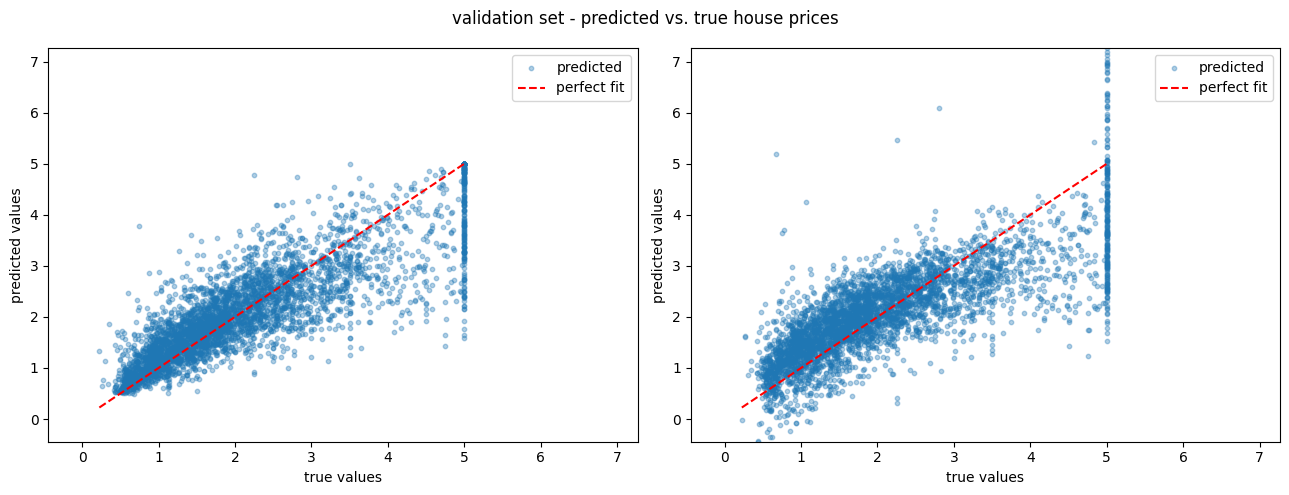

In [6]:
# we should use linear regression prediction range range as shared y-axis
y_min = pred_linreg.min()
y_max = pred_linreg.max()

fig, axes = plt.subplots(1,2, figsize=(13,5), sharey = False)

for ax, preds, title in zip(axes, [pred_knn, pred_linreg], ["kNN: k = 10", "Linear Regression"]):
    ax.scatter(y_val, preds, alpha=0.35, s = 10, label = "predicted")
    ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--", linewidth= 1.5, label='perfect fit')
    ax.set_xlim(y_min, y_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel("true values")
    ax.set_ylabel("predicted values")
    ax.legend()

plt.suptitle("validation set - predicted vs. true house prices")
plt.tight_layout()
plt.show()

Evaluating the Best Model On Our Test Set

In [7]:
# we should choose the model with lower validation MSE.

best_name = "kNN" if mse_knn < mse_linreg else "Linear Regression"
best_pipe = pipe_knn if mse_knn < mse_linreg else pipe_linreg

pred_test = best_pipe.predict(X_test)
print(f"Best model on validation: {best_name}")
print(f"Test MSE : {mean_squared_error(y_test, pred_test):.4f}")
print(f"Test R²  : {r2_score(y_test, pred_test):.4f}")

Best model on validation: kNN
Test MSE : 0.4110
Test R²  : 0.6864


Derivation of Linear Regression Coefficients

In [8]:
lin_model = pipe_linreg.named_steps['linearregression']
coefs = lin_model.coef_
intercept = lin_model.intercept_

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs, 'Abs Value' : np.abs(coefs)}).sort_values('Abs Value', ascending = False)
print(f"Intercept: {intercept:.4f}\n")
print(coef_df.to_string(index=False))

Intercept: 2.0681

   Feature  Coefficient  Abs Value
  Latitude    -0.888213   0.888213
 Longitude    -0.861907   0.861907
    MedInc     0.860253   0.860253
 AveBedrms     0.312087   0.312087
  AveRooms    -0.280392   0.280392
  HouseAge     0.120007   0.120007
  AveOccup    -0.026158   0.026158
Population    -0.009574   0.009574


Part B: Polynomial Regression and Overfitting

Generating Noisy Dataset With the Help of Instructions

In [9]:
np.random.seed(42)
X_poly = np.random.uniform(-2.5, 2.5, size =(150,1))
y_poly =  (-1 * X_poly[:, 0]**5 + 3 * X_poly[:, 0]**3 - 2 * X_poly[:, 0] + np.random.normal(0, 3, 150))

print("X shape:", X_poly.shape)
print("y shape:", y_poly.shape)

X shape: (150, 1)
y shape: (150,)


Train / Test Splitting with 70/30 Ratio

In [10]:
X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(X_poly, y_poly, test_size = 0.30, random_state = 42)
print(f"Train: {X_poly_train.shape[0]} samples")
print(f"Test : {X_poly_test.shape[0]} samples")

Train: 105 samples
Test : 45 samples


Creating a Loop for Polynomial Degree from 1 to 15, Recording Train / Test MSE Values Respectively

In [11]:
degrees = list(range(1,16))
train_mse = []
test_mse = []

for d in degrees:
    pipe = make_pipeline(PolynomialFeatures(degree = d, include_bias = True), StandardScaler(), LinearRegression())
    pipe.fit(X_poly_train, y_poly_train)

    train_mse.append(mean_squared_error(y_poly_train, pipe.predict(X_poly_train)))
    test_mse.append(mean_squared_error(y_poly_test, pipe.predict(X_poly_test)))


print(f"{'Degree':>7} {'Train MSE':>12} {'Test MSE':>12}")
print("-" * 35)
for d, tr, te in zip(degrees, train_mse, test_mse):
    print(f"{d:>7} {tr:>12.4f} {te:>12.4f}")

 Degree    Train MSE     Test MSE
-----------------------------------
      1      84.1935     141.4349
      2      84.1729     140.3885
      3      22.8127      22.2723
      4      22.1837      20.0457
      5       9.6771       7.8240
      6       9.3251       8.5356
      7       9.2798       8.5364
      8       9.0163       7.3659
      9       8.9063       8.0034
     10       8.8492       8.3292
     11       8.5587       8.7361
     12       8.5586       8.7775
     13       8.5091      10.4913
     14       8.4808      14.3323
     15       8.3600      29.4855


Plot the Training MSE vs. Test MSE (in log scale)

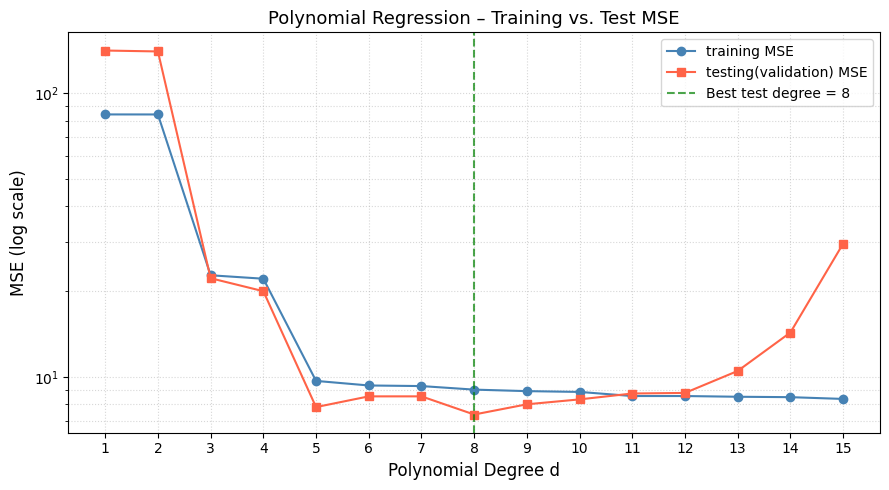

In [12]:
fig, ax = plt.subplots(figsize = (9,5))

ax.plot(degrees, train_mse, 'o-', color = 'steelblue', label = "training MSE")
ax.plot(degrees, test_mse, 's-', color = 'tomato', label = "testing(validation) MSE")

# we should mark the best testing degree at this point

best_degree = degrees[np.argmin(test_mse)]
best_mse = min(test_mse)

ax.axvline(best_degree, color='green', linestyle='--', alpha=0.7,
           label=f'Best test degree = {best_degree}')

ax.set_yscale('log')          # logarithmic y-axis as required
ax.set_xlabel('Polynomial Degree d', fontsize=12)
ax.set_ylabel('MSE (log scale)', fontsize=12)
ax.set_title('Polynomial Regression – Training vs. Test MSE', fontsize=13)
ax.set_xticks(degrees)
ax.legend()
ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig("partB_poly_mse.png", dpi=150, bbox_inches="tight")
plt.show()